# Treinamento com intrusion_gap

Fluxo replicando o notebook `model_training` para o dataset `intrusion_gap`, focando em seleção de características (mesmos 5 métodos) e avaliação de modelos em múltiplas estratégias de cross-validation estratificada para lidar com o forte desbalanceamento (1898 intrusão vs 78995 normal).

In [1]:
# Imports principais e configuração de ambiente
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import defaultdict

from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
    RepeatedStratifiedKFold,
    train_test_split,
    cross_validate,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.metrics import confusion_matrix, matthews_corrcoef
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Verifica disponibilidade do mrmr-selection
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except Exception:
    MRMR_AVAILABLE = False

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")

In [3]:
# Carregar o dataset DoS
intrusion_path = Path("../data/processed/intrusion_gap.csv")
df = pd.read_csv(intrusion_path)

print(f"📊 Shape do dataset: {df.shape}")
print(f"📝 Colunas: {df.shape[1]}")
print(f"📋 Registros: {df.shape[0]}")
print(f"\n🏷️ Distribuição do Label ('type'):")
print(df['type'].value_counts())

📊 Shape do dataset: (80893, 67)
📝 Colunas: 67
📋 Registros: 80893

🏷️ Distribuição do Label ('type'):
type
normal       78995
intrusion     1898
Name: count, dtype: int64


In [4]:
# Selecionar apenas features numéricas
num_df = df.select_dtypes(include=['int64', 'float64'])

# Colunas a remover (irrelevantes para detecção de ataques)
colunas_para_remover = [
    'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid', 
    'frame.time_relative', 'tcp.srcport', 'tcp.dstport', 
    'frame.coloring_rule.name', 'frame.coloring_rule.string', 
    'frame.comment', 'frame.comment.expert', 'frame.encap_type', 
    'frame.file_off', 'frame.ignored', 'frame.incomplete', 
    'frame.interface_id', 'frame.interface_name', 'frame.link_nr', 
    'frame.marked', 'frame.md5_hash', 'frame.number', 'frame.offset_shift',
    'mqtt.msgid', 'mqtt.username', 'mqtt.passwd', 
    'mqtt.willmsg', 'mqtt.willtopic'
]

# Remover colunas existentes no dataframe
colunas_existentes = [c for c in colunas_para_remover if c in num_df.columns]
X = num_df.drop(columns=colunas_existentes, errors='ignore')

# Tratar valores ausentes e infinitos
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

# Encode do label (target)
le = LabelEncoder()
y = le.fit_transform(df['type'])

print(f"✅ Features numéricas após limpeza: {X.shape[1]}")
print(f"🎯 Classes: {le.classes_}")
print(f"📊 Shape X: {X.shape}, y: {y.shape}")

✅ Features numéricas após limpeza: 30
🎯 Classes: ['intrusion' 'normal']
📊 Shape X: (80893, 30), y: (80893,)


In [16]:
# Funções auxiliares de seleção de características
K = 15  # quantidade padrão de atributos a manter por método


def select_mrmr(X_df, y_vec, k=K):
    """Seleciona k features pelo critério mRMR se disponível."""
    if not MRMR_AVAILABLE:
        return []
    return list(mrmr_classif(X=X_df, y=y_vec, K=k))


def select_fisher_kbest(X_df, y_vec, k=K):
    selector = SelectKBest(score_func=f_classif, k=min(k, X_df.shape[1]))
    selector.fit(X_df, y_vec)
    return list(X_df.columns[selector.get_support()])


def fisher_score_manual(X_df, y_vec, k=K):
    # Razão entre variância entre classes e intra-classes
    scores = {}
    classes = np.unique(y_vec)
    for col in X_df.columns:
        between = 0.0
        within = 0.0
        overall_mean = X_df[col].mean()
        for cls in classes:
            cls_vals = X_df.loc[y_vec == cls, col]
            cls_mean = cls_vals.mean()
            between += len(cls_vals) * (cls_mean - overall_mean) ** 2
            within += len(cls_vals) * cls_vals.var()
        scores[col] = between / (within + 1e-8)
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [feat for feat, _ in ranked[:k]]


def select_pearson(X_df, y_vec, k=K):
    corr = X_df.apply(lambda col: np.abs(np.corrcoef(col, y_vec)[0, 1]))
    corr = corr.replace([np.inf, -np.inf], 0).fillna(0)
    ranked = corr.sort_values(ascending=False)
    return list(ranked.head(min(k, len(ranked))).index)


def select_extratrees(X_df, y_vec, k=K):
    model = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced")
    model.fit(X_df, y_vec)
    importances = pd.Series(model.feature_importances_, index=X_df.columns)
    ranked = importances.sort_values(ascending=False)
    return list(ranked.head(min(k, len(ranked))).index)


def select_linsvc(X_df, y_vec, k=K):
    svc = LinearSVC(C=0.1, penalty="l1", dual=False, random_state=42)
    svc.fit(StandardScaler().fit_transform(X_df), y_vec)
    coefs = np.abs(svc.coef_[0]) if svc.coef_.ndim == 2 else np.abs(svc.coef_)
    coef_series = pd.Series(coefs, index=X_df.columns)
    ranked = coef_series.sort_values(ascending=False)
    return list(ranked.head(min(k, len(ranked))).index)


def select_lasso(X_df, y_vec, k=K):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)
    lasso = LassoCV(cv=5, random_state=42, n_jobs=-1)
    lasso.fit(X_scaled, y_vec)
    coefs = pd.Series(np.abs(lasso.coef_), index=X_df.columns)
    ranked = coefs.sort_values(ascending=False)
    return list(ranked.head(min(k, len(ranked))).index)


def select_low_variance(X_df, threshold=0.05):
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X_df)
    return list(X_df.columns[selector.get_support()])


def summarize_feature_sets(feature_sets):
    rows = []
    for method, feats in feature_sets.items():
        for rank, feat in enumerate(feats, 1):
            rows.append({"method": method, "feature": feat, "rank": rank})
    return pd.DataFrame(rows)

In [17]:
# Executa os seletores (mesmos 5 métodos do notebook base + variância)
feature_sets = {
    "mrmr": select_mrmr(X, y),
    "fisher_kbest": select_fisher_kbest(X, y),
    "fisher_manual": fisher_score_manual(X, y),
    "pearson": select_pearson(X, y),
    "extratrees": select_extratrees(X, y),
    "linsvc_l1": select_linsvc(X, y),
    "lasso": select_lasso(X, y),
    "low_variance": select_low_variance(X),
}

# Remove seleções vazias (caso mRMR não esteja instalado)
feature_sets = {k: v for k, v in feature_sets.items() if len(v) > 0}

summary_df = summarize_feature_sets(feature_sets)
print("Métodos disponíveis:", list(feature_sets.keys()))
summary_df.head()

100%|██████████| 12/12 [00:02<00:00,  4.39it/s]


Métodos disponíveis: ['mrmr', 'fisher_kbest', 'fisher_manual', 'pearson', 'extratrees', 'linsvc_l1', 'lasso', 'low_variance']


,method,feature,rank
0,mrmr,mqtt.kalive,1
1,mrmr,publish_gap,2
2,mrmr,mqtt.msgtype,3
3,mrmr,frame.cap_len,4
4,mrmr,mqtt.len,5


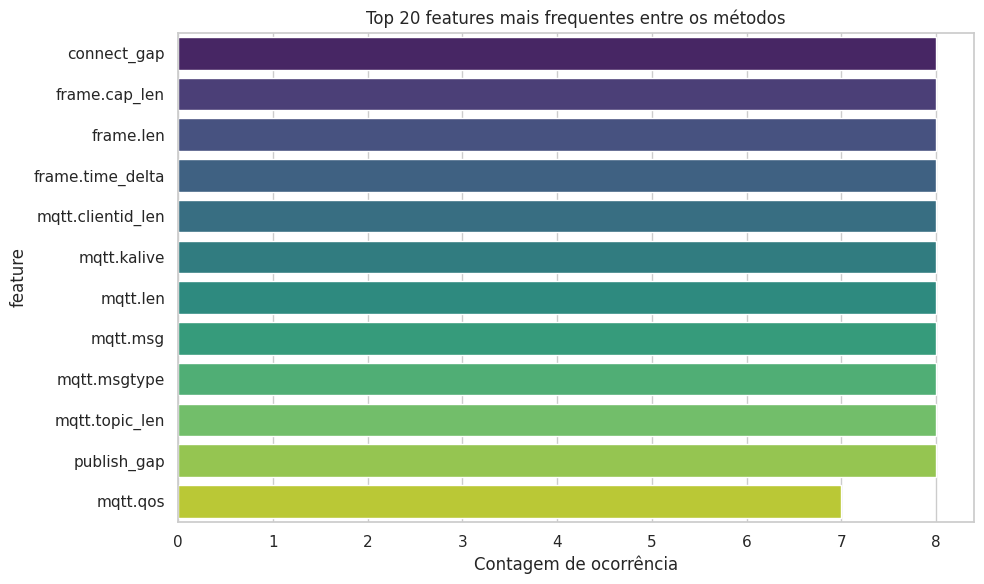

In [18]:
# Visualiza frequência de seleção por método
if not summary_df.empty:
    freq = summary_df.groupby("feature").size().sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=freq.values, y=freq.index, palette="viridis")
    plt.title("Top 20 features mais frequentes entre os métodos")
    plt.xlabel("Contagem de ocorrência")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum conjunto de features disponível para plot.")

In [19]:
# Define modelos e estratégias de cross-validation (5 modos diferentes)
class_weights = {0: 1.0, 1: max(1.0, (len(y) - np.sum(y)) / max(np.sum(y), 1))}

model_factories = {
    "rf": lambda: RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
        class_weight=class_weights,
    ),
    "logreg": lambda: Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    max_iter=200,
                    class_weight="balanced",
                    solver="lbfgs",
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "svc_rbf": lambda: Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                SVC(
                    probability=True,
                    class_weight="balanced",
                    kernel="rbf",
                    gamma="scale",
                    random_state=42,
                ),
            ),
        ]
    ),
    "knn": lambda: Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=7))]),
    "nb": lambda: GaussianNB(),
    "dt": lambda: DecisionTreeClassifier(max_depth=None, random_state=42, class_weight=class_weights),
}

cv_strategies = {
    "StratKFold-5": StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    "StratKFold-10": StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    "StratShuffle-20": StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42),
    "StratShuffle-10": StratifiedShuffleSplit(n_splits=5, test_size=0.1, random_state=42),
    "RepeatedStrat-5x2": RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42),
}

In [20]:
# Função de avaliação cruzada por conjunto de features e estratégia de CV
scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc_ovr",
}


def evaluate_feature_sets_cv(X_df, y_vec, feature_sets, model_factories, cv_strategies):
    results = []
    for feat_name, feat_list in feature_sets.items():
        X_sel = X_df[feat_list]
        for model_name, factory in model_factories.items():
            for cv_name, cv in cv_strategies.items():
                model = factory()
                cv_res = cross_validate(
                    model,
                    X_sel,
                    y_vec,
                    cv=cv,
                    scoring=scoring,
                    n_jobs=-1,
                    return_estimator=False,
                )
                for metric, values in cv_res.items():
                    if not metric.startswith("test_"):
                        continue
                    metric_name = metric.replace("test_", "")
                    results.append(
                        {
                            "feature_set": feat_name,
                            "model": model_name,
                            "cv": cv_name,
                            "metric": metric_name,
                            "mean": np.mean(values),
                            "std": np.std(values),
                        }
                    )
    return pd.DataFrame(results)


results_df = evaluate_feature_sets_cv(X, y, feature_sets, model_factories, cv_strategies)
results_df.head()

KeyboardInterrupt: 

In [ ]:
# Ranking dos melhores modelos por conjunto de features usando F1 macro
if not results_df.empty:
    f1_df = results_df[results_df["metric"] == "f1_macro"].copy()
    best_per_set = (
        f1_df.sort_values(["feature_set", "mean"], ascending=[True, False])
        .groupby(["feature_set", "cv"], as_index=False)
        .first()
    )
    display(best_per_set.head(20))
else:
    print("Execute a célula anterior para obter resultados de CV.")

In [ ]:
# Plot comparativo: F1 macro médio por feature set e modelo (melhor CV de cada um)
if not results_df.empty:
    plot_df = results_df[results_df["metric"] == "f1_macro"].copy()
    # Seleciona a melhor combinação por feature_set + model (maior média entre CVs)
    plot_df = plot_df.sort_values(["feature_set", "model", "mean"], ascending=[True, True, False])
    plot_df = plot_df.groupby(["feature_set", "model"], as_index=False).first()

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_df, x="mean", y="feature_set", hue="model", palette="tab20")
    plt.xlabel("F1 macro (média)")
    plt.ylabel("Conjunto de features")
    plt.title("Comparação de F1 macro por seleção de características e modelo")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum resultado para plotar. Execute as avaliações de CV primeiro.")

In [ ]:
# Avaliação simples hold-out no melhor conjunto (primeiro da lista) para gerar matrizes de confusão/ROC
if feature_sets:
    best_set_name = list(feature_sets.keys())[0]
    best_feats = feature_sets[best_set_name]
    X_sel = X[best_feats]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sel, y, test_size=0.2, random_state=42, stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight=class_weights
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    bal = balanced_accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    print(f"Hold-out | set={best_set_name} | acc={acc:.3f} | f1={f1:.3f} | bal_acc={bal:.3f} | roc_auc={roc:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title(f"Matriz de confusão - {best_set_name}")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum conjunto de features disponível para avaliação hold-out.")

## Próximos passos
- Rodar as células de seleção e avaliação para comparar os 5 modos de cross-validation.
- Revisar o melhor par `feature_set` + `modelo` olhando F1 macro e balanced accuracy.
- Se necessário, ajustar hiperparâmetros dos modelos campeões e repetir os gráficos.

In [ ]:
# Seletores reusáveis para CV (recalculados a cada fold)
def build_selector_functions(K_top=K):
    def sel_mrmr(X_tr, y_tr):
        if not MRMR_AVAILABLE:
            return []
        K_use = min(K_top, X_tr.shape[1])
        try:
            return list(mrmr_classif(X=X_tr, y=y_tr, K=K_use))
        except Exception:
            return []

    def sel_fisher(X_tr, y_tr):
        scores = {}
        classes = np.unique(y_tr)
        for col in X_tr.columns:
            between = 0.0
            within = 0.0
            overall_mean = X_tr[col].mean()
            for cls in classes:
                cls_vals = X_tr.loc[y_tr == cls, col]
                cls_mean = cls_vals.mean()
                between += len(cls_vals) * (cls_mean - overall_mean) ** 2
                within += len(cls_vals) * cls_vals.var()
            scores[col] = between / (within + 1e-8)
        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return [feat for feat, _ in ranked[: min(K_top, len(ranked))]]

    def sel_pearson(X_tr, y_tr):
        corr = X_tr.apply(lambda col: np.abs(np.corrcoef(col, y_tr)[0, 1]))
        corr = corr.replace([np.inf, -np.inf], 0).fillna(0)
        ranked = corr.sort_values(ascending=False)
        return list(ranked.head(min(K_top, len(ranked))).index)

    def sel_extratrees(X_tr, y_tr):
        model = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced")
        model.fit(X_tr, y_tr)
        imp = pd.Series(model.feature_importances_, index=X_tr.columns)
        return list(imp.sort_values(ascending=False).head(min(K_top, len(imp))).index)

    def sel_linsvc(X_tr, y_tr):
        scaler_local = StandardScaler()
        X_scaled_tr = scaler_local.fit_transform(X_tr)
        svc_local = LinearSVC(C=0.1, penalty="l1", dual=False, random_state=42)
        svc_local.fit(X_scaled_tr, y_tr)
        coef_series = pd.Series(np.abs(svc_local.coef_).ravel(), index=X_tr.columns)
        return list(coef_series.sort_values(ascending=False).head(min(K_top, len(coef_series))).index)

    def sel_lasso(X_tr, y_tr):
        scaler_local = StandardScaler()
        X_scaled_tr = scaler_local.fit_transform(X_tr)
        lasso_local = LassoCV(cv=3, random_state=42, n_jobs=-1)
        lasso_local.fit(X_scaled_tr, y_tr)
        coef_series = pd.Series(np.abs(lasso_local.coef_), index=X_tr.columns)
        return list(coef_series.sort_values(ascending=False).head(min(K_top, len(coef_series))).index)

    def sel_low_variance(X_tr, y_tr):
        selector_local = VarianceThreshold(threshold=0.0)
        selector_local.fit(X_tr)
        return list(X_tr.columns[selector_local.get_support(indices=True)])

    return {
        "mRMR": sel_mrmr,
        "Fisher": sel_fisher,
        "Pearson": sel_pearson,
        "ExtraTrees": sel_extratrees,
        "LinearSVC_L1": sel_linsvc,
        "LassoCV": sel_lasso,
        "LowVariance": sel_low_variance,
    }

selector_funcs_cv = build_selector_functions()
print("Seletores disponíveis para CV:", list(selector_funcs_cv.keys()))

In [ ]:
# Avaliação de seletores com CV estratificada e métricas macro
cv_models = {
    "RandomForest": lambda: RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1, class_weight=class_weights
    ),
    "LogisticRegression": lambda: Pipeline(
        [("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=200, n_jobs=-1, class_weight="balanced"))]
    ),
    "GaussianNB": lambda: GaussianNB(),
    "SVM_RBF": lambda: Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, class_weight="balanced", random_state=42)),
        ]
    ),
    "DecisionTree": lambda: DecisionTreeClassifier(random_state=42, class_weight=class_weights),
}


def evaluate_selector_cv(selector_name, selector_fn, X_full, y_full, cv_splits=5):
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    rows = []
    for model_name, factory in cv_models.items():
        metrics_acc = []
        metrics_prec = []
        metrics_rec = []
        metrics_f1 = []
        metrics_bal = []
        metrics_mcc = []
        metrics_roc = []

        for train_idx, val_idx in skf.split(X_full, y_full):
            X_tr, X_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
            y_tr, y_val = y_full[train_idx], y_full[val_idx]

            cols = selector_fn(X_tr, y_tr)
            if not cols:
                continue

            model = factory()
            model.fit(X_tr[cols], y_tr)
            y_pred = model.predict(X_val[cols])

            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_val[cols])[:, 1]
            else:
                try:
                    scores = model.decision_function(X_val[cols])
                    y_proba = 1 / (1 + np.exp(-scores))
                except Exception:
                    y_proba = None

            metrics_acc.append(accuracy_score(y_val, y_pred))
            metrics_prec.append(precision_score(y_val, y_pred, average="macro", zero_division=0))
            metrics_rec.append(recall_score(y_val, y_pred, average="macro", zero_division=0))
            metrics_f1.append(f1_score(y_val, y_pred, average="macro", zero_division=0))
            metrics_bal.append(balanced_accuracy_score(y_val, y_pred))
            metrics_mcc.append(matthews_corrcoef(y_val, y_pred))
            if y_proba is not None:
                metrics_roc.append(roc_auc_score(y_val, y_proba))

        if metrics_acc:
            rows.append(
                {
                    "selector": selector_name,
                    "model": model_name,
                    "accuracy_mean": float(np.mean(metrics_acc)),
                    "accuracy_std": float(np.std(metrics_acc)),
                    "precision_mean": float(np.mean(metrics_prec)),
                    "precision_std": float(np.std(metrics_prec)),
                    "recall_mean": float(np.mean(metrics_rec)),
                    "recall_std": float(np.std(metrics_rec)),
                    "f1_mean": float(np.mean(metrics_f1)),
                    "f1_std": float(np.std(metrics_f1)),
                    "balanced_accuracy_mean": float(np.mean(metrics_bal)),
                    "balanced_accuracy_std": float(np.std(metrics_bal)),
                    "mcc_mean": float(np.mean(metrics_mcc)),
                    "mcc_std": float(np.std(metrics_mcc)),
                    "roc_auc_mean": float(np.mean(metrics_roc)) if metrics_roc else np.nan,
                    "roc_auc_std": float(np.std(metrics_roc)) if metrics_roc else np.nan,
                }
            )
    return pd.DataFrame(rows)


def plot_selector_results(df_sel, title):
    if df_sel.empty:
        print("Sem resultados para plotar.")
        return
    metrics_to_plot = [
        ("accuracy_mean", "Accuracy"),
        ("balanced_accuracy_mean", "Balanced Acc"),
        ("f1_mean", "F1 macro"),
        ("precision_mean", "Precision macro"),
        ("recall_mean", "Recall macro"),
        ("mcc_mean", "MCC"),
        ("roc_auc_mean", "ROC AUC"),
    ]
    ncols = 3
    nrows = int(np.ceil(len(metrics_to_plot) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = axes.flatten()
    for ax, (metric, label) in zip(axes, metrics_to_plot):
        err_col = metric.replace("_mean", "_std")
        vals = df_sel[metric]
        errs = df_sel[err_col]
        bars = ax.barh(df_sel["model"], vals, xerr=errs, color=plt.cm.Greens(np.linspace(0.4, 0.9, len(df_sel))), capsize=4)
        ax.invert_yaxis()
        ax.set_title(label)
        ax.set_xlabel(label)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f"{val:.3f}" if np.isfinite(val) else "nan", va="center", fontsize=9)
    for j in range(len(metrics_to_plot), len(axes)):
        axes[j].axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
# Executa avaliação por seletor e plota métricas
selector_results = {}
for sel_name, sel_fn in selector_funcs_cv.items():
    df_sel = evaluate_selector_cv(sel_name, sel_fn, X, y, cv_splits=5)
    selector_results[sel_name] = df_sel
    print(f"Resultado - {sel_name}")
    display(df_sel)
    plot_selector_results(df_sel, f"{sel_name} - Resultados CV")

# Consolida para análise agregada
all_sel_results = pd.concat(selector_results.values(), ignore_index=True) if selector_results else pd.DataFrame()
all_sel_results.head()

In [ ]:
# Heatmap de seleção e histograma de frequência (baseado nos feature_sets iniciais)
if feature_sets:
    selection_map = {name: set(feats) for name, feats in feature_sets.items()}
    all_feats = sorted({f for feats in selection_map.values() for f in feats})
    selection_df = pd.DataFrame({m: [1 if f in feats else 0 for f in all_feats] for m, feats in selection_map.items()}, index=all_feats)
    selection_df["times_selected"] = selection_df.sum(axis=1)
    print(selection_df["times_selected"].sort_values(ascending=False).head(20))

    plt.figure(figsize=(10, max(6, len(all_feats)*0.15)))
    sns.heatmap(selection_df.drop(columns=["times_selected"]), cmap="YlGnBu", cbar=True, annot=False)
    plt.title("Matriz de seleção (1 = feature escolhida pelo método)")
    plt.xlabel("Métodos")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    sns.histplot(selection_df["times_selected"], bins=range(0, selection_df["times_selected"].max() + 2), kde=False, color="#2a9d8f")
    plt.title("Distribuição de frequência de seleção por feature")
    plt.xlabel("Número de métodos que selecionaram a feature")
    plt.ylabel("Contagem de features")
    plt.tight_layout()
    plt.show()
else:
    print("feature_sets vazio; execute a célula de seleção de features antes deste bloco.")

## Dicas de execução
- Execute as células na ordem: carga de dados → seletores → avaliação por CV → gráficos/heatmap.
- As avaliações por seletor usam 5 folds estratificados e múltiplos modelos; podem demorar (dataset grande). Ajuste `n_estimators` ou reduza `cv_splits` se necessário.
- Os gráficos finais replicam o padrão de comparação do notebook `model_training`.